Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

## Import the libraries and the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import roc_curve, auc

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## Check for missing variables and correct as needed. Once you've completed the cleaning again create a function that will do this for you in the future. In the submission, include only the function and the function call.

In [3]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [4]:
def data_cleaning(df, column):
    # convert object columns to categorical
    cat = df.select_dtypes(include=['object']).columns.tolist()
    df[cat] = df[cat].astype('category')

    # drop irrelevant columns
    df = df.drop(column, axis=1)
    
    # drop NA
    df = df.dropna()

    return df

movie_metadata = data_cleaning(movie_metadata,['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'])

In [5]:
#use one hot encoding for other categorical variables
encoder = OneHotEncoder(sparse_output=False)

In [6]:
movie_metadata['imdb_score']=movie_metadata['imdb_score'].astype('float64')

In [7]:
# Categorize imdb_score into three classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 8.0 else "low"
)

#print(movie_metadata["imdb_score"].value_counts())

movie_metadata["imdb_score"] = OrdinalEncoder().fit_transform(movie_metadata[['imdb_score']])

#print(movie_metadata["imdb_score"].value_counts())

In [8]:
## encode directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

In [9]:
## encode title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

In [10]:
## encode first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [11]:
## encode country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [12]:
## encode content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)

In [13]:
# encode language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

In [14]:
# encode color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')

#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

## 5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [15]:
#calculate the prevalence
print(movie_metadata['imdb_score'].value_counts()) #633/3122
print('The prevalence is: ',635/(2835+635+299))

imdb_score
1.0    3558
0.0     211
Name: count, dtype: int64
The prevalence is:  0.16847970283894934


This number means that the possibility of predicting a movie with a high imdb score is 0.169.

## 6 Split your data into test, tune, and train. (80/10/10)

In [16]:
X= movie_metadata.drop(columns=['imdb_score'])
y= movie_metadata['imdb_score']

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state=49)

## 7 Create the kfold object for cross validation.

In [18]:
from sklearn.model_selection import RepeatedStratifiedKFold

kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

## 8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter 

In [19]:
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}

## 9 Build the classifier object 

In [20]:
cl= DecisionTreeClassifier(random_state=1000)

## 10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [21]:
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')

## 11 Fit the model to the training data.

In [22]:
#execute search on our training data, this may take a few seconds ...
model = search.fit(X_train, y_train)

## 12 What is the best depth value?

In [23]:
#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print(best)
print(model.best_score_)
#print(best.score(X_train, y_train))

DecisionTreeClassifier(max_depth=3, random_state=1000)
0.9003763625932301


The best depth value is 3.

## 13 Print out the model

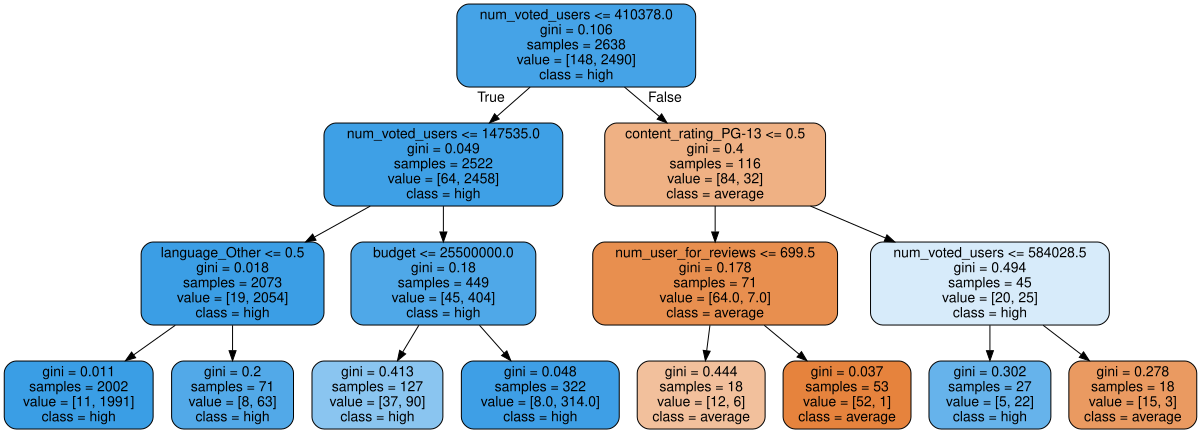

In [24]:
dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns, #feature names from dataset
               filled=True, 
                rounded=True, 
                class_names = ['average','high']) #classification labels 
               
graph=graphviz.Source(dot_data)
graph

## 14 View the results, comment on how the model performed using several evaluation metrics. (Use multiple methods)

### ROC and AUC

In [25]:
#Let's extract these scores, using our function!

#Scores: 

auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.769293,0.986586,0.769293,0.049865,0.006456,0.049865
2,0.859393,0.993896,0.702043,0.059015,0.005970,0.064645
3,0.900376,0.994458,0.739610,0.058783,0.004878,0.052649
4,0.889940,0.989558,0.765970,0.062102,0.006273,0.063006
5,0.860192,0.984016,0.784627,0.063613,0.007556,0.065444
6,0.805454,0.984498,0.785725,0.091959,0.006910,0.068441
7,0.785239,0.981365,0.792968,0.081863,0.008103,0.061526
8,0.813841,0.980884,0.798823,0.084339,0.009283,0.062000
9,0.807336,0.977671,0.798645,0.070518,0.009164,0.062130
10,0.807802,0.977028,0.805133,0.080459,0.009640,0.061894


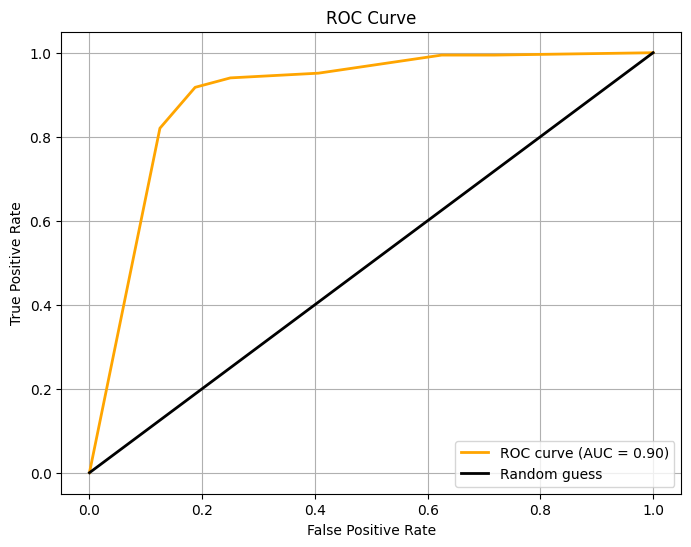

In [27]:
from sklearn.metrics import roc_curve, auc
# Get predicted probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc_score = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='-', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

The area under curve of the model is 0.9 on the test data, which indicates that the model is decent.

### F1 Score

In [28]:
F1_score = metrics.f1_score(y_test, model.predict(X_test),average='weighted')
print(F1_score)

0.9523332329747565


F1-score works better for unbalanced datasets. In this case, the prevalence is 0.2, which means there are way more average imdb-ratings than high ones. Therefore, the F1-score turns out to be useful. An F1-score of 0.952 is very decent, which means the model's ability to predict is good.

### Accuracy

In [29]:
#calculate the accuracy
accuracy = metrics.accuracy_score(y_test, model.predict(X_test))
print(accuracy)

0.9593639575971732


The accuracy of the model is 0.96, which is also a very high number.

## 15 Which variables appear to be contributing the most (variable importance) 

In [30]:
#Variable importance for the best estimator, how much weight does each feature have in determining the classification?
imp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(imp)

                              importance
num_voted_users                 0.811569
budget                          0.085017
content_rating_PG-13            0.075596
num_user_for_reviews            0.017464
language_Other                  0.010353
actor_1_name_Famous             0.000000
actor_1_name_Other              0.000000
country_Big Country Producer    0.000000
country_Other                   0.000000
content_rating_Other            0.000000
num_critic_for_reviews          0.000000
title_year_new                  0.000000
content_rating_R                0.000000
language_English                0.000000
language_French                 0.000000
color_Black and White           0.000000
title_year_old                  0.000000
director_name_Other             0.000000
title_year_middle               0.000000
duration                        0.000000
director_name_Famous            0.000000
movie_facebook_likes            0.000000
aspect_ratio                    0.000000
actor_2_facebook

Number of voted users is the most important feature.

Axes(0.125,0.11;0.775x0.77)


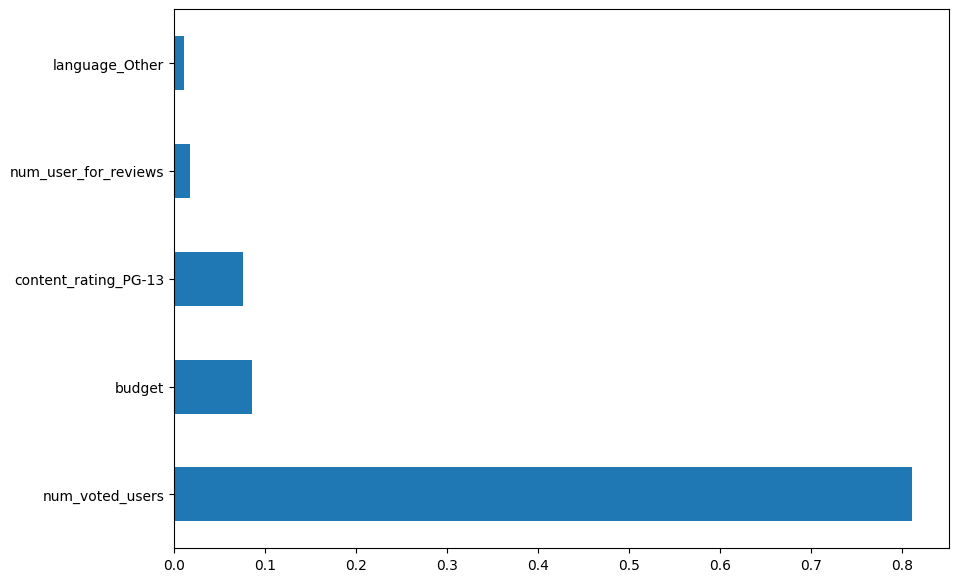

In [31]:
#Graph variable importance
plt.figure(figsize=(10,7))
print(imp.importance.nlargest(5).plot(kind='barh'))

## 16 Use the predict method on the tune data and print out the results. 17 How does the model perform on the tune data?

In [32]:
tune_model = search.fit(X_tune, y_tune)
print(model.best_score_)

0.7076222921034244


## 18 Print out the confusion matrix for the tune data, what does it tell you about the model?

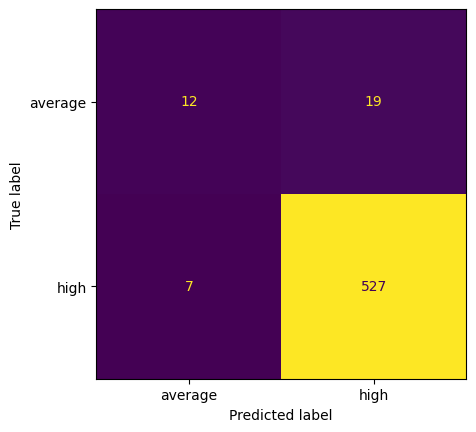

In [33]:
print(ConfusionMatrixDisplay.from_estimator(best,X_tune,y_tune, display_labels = ['average','high'], colorbar=False))

- The true positives rate is 527/(527+7) = 0.98, the true negatives rate is 12/(12+19) = 0.39, the false positives rate is 7/(527+7) = 0.02, and the false negatives rate is 19/(19+12) = 0.61.

- The sensitivity of the model is 527/(527+19) = 0.97, and the specificity is 12/(12+7) = 0.63.

- The model has a high sensitivity, which means the model is good at predicting high imdb-ratings. However, the model has a lower specificity, which means the model is not as good at predicting average imdb-ratings.

## 19 What are the top 3 movies based on the test set? Which variables are most important in predicting the top 3 movies?

In [34]:
# Calculate the probability for 'high' class
y_prob = best.predict_proba(X_test)[:, 1]

# Attach predictions to original X_test for context
X_test_copy = X_test.copy()
movie_test=pd.read_csv("../data/movie_metadata.csv")
X_test_copy['movie_title'] = movie_test['movie_title']  # Make sure you have the titles
X_test_copy['prob_high'] = y_prob

# Sort and print top 3 movies with highest probability of being 'high'
top_3 = X_test_copy.sort_values(by='prob_high', ascending=False).head(3)
print("Top 3 Movies Based on Predicted Probability of High Score:")
print(top_3[['movie_title', 'prob_high']])

# Feature importance
importances = pd.DataFrame(best.feature_importances_, index=X.columns, columns=['importance']).sort_values('importance', ascending=False)
print("\nTop Predictive Features:")
print(importances.head(5))

Top 3 Movies Based on Predicted Probability of High Score:
           movie_title  prob_high
1992  Say It Isn't So    0.994505
1569  The Good German    0.994505
1778          Rob Roy    0.994505

Top Predictive Features:
                      importance
num_voted_users         0.811569
budget                  0.085017
content_rating_PG-13    0.075596
num_user_for_reviews    0.017464
language_Other          0.010353


## 20 Use a different hyperparameter for the grid search function and go through the process above again using the tune set.

In [35]:
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.769293,0.986586,0.769293,0.049865,0.006456,0.049865
2,0.859393,0.993896,0.702043,0.059015,0.005970,0.064645
3,0.900376,0.994458,0.739610,0.058783,0.004878,0.052649
4,0.889940,0.989558,0.765970,0.062102,0.006273,0.063006
5,0.860192,0.984016,0.784627,0.063613,0.007556,0.065444
6,0.805454,0.984498,0.785725,0.091959,0.006910,0.068441
7,0.785239,0.981365,0.792968,0.081863,0.008103,0.061526
8,0.813841,0.980884,0.798823,0.084339,0.009283,0.062000
9,0.807336,0.977671,0.798645,0.070518,0.009164,0.062130
10,0.807802,0.977028,0.805133,0.080459,0.009640,0.061894


From the previous ROC_AUC analysis, we can see that recall is the best scoring metrics for this model since its score is the highest

In [36]:
print(model.best_score_)

#fit the model with the tune data
model = search.fit(X_tune, y_tune)

#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print('The best params is:',model.best_params_)

#improve the performance of the model by optimizing the parameters
improved_param={"max_depth" : [5]}
improved_scoring = ['recall']
cl = DecisionTreeClassifier(random_state=1000)
improved_search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='recall')

#rebuild the model with the new parameters
improved_model = improved_search.fit(X_test, y_test)
improved_score = best.score(X_tune,y_tune)
print(improved_score)

0.7076222921034244
The best params is: {'max_depth': 9}
0.9982300884955753


In [37]:
# Ensure model is already fitted
best.fit(X_tune, y_tune)

# Predict on X_test
y_probs = best.predict_proba(X_tune)[:, 1]

# Create clean copy of test set
X_tune_copy = X_tune.copy().reset_index(drop=True)

# Load movie metadata
movie_metadata = pd.read_csv("../data/movie_metadata.csv")

# Get movie titles that match X_test rows
movie_test = movie_metadata.loc[X_tune.index].reset_index(drop=True)

# Attach titles and probabilities
X_tune_copy['movie_title'] = movie_test['movie_title'].values
X_tune_copy['prob_high'] = y_probs

# Show top 3 movies by high-score probability
top_3 = X_tune_copy[['movie_title', 'prob_high']].sort_values(by='prob_high', ascending=False).head(3)

print("Top 3 Movies Based on Predicted Probability of High Score:")
print(top_3)

Top 3 Movies Based on Predicted Probability of High Score:
                  movie_title  prob_high
0                     Legion         1.0
375  Avengers: Age of Ultron         1.0
369                Annabelle         1.0


Legion's imdb rating is 8.1, Avengers: Age of Ultron's imdb rating is 7.3, and Annabelle's imdb rating is 6.5.

## 21 Did the model improve with the new hyperparameter search?

The model's score is 0.99. There is an improvement in the model performance compared with the accuracy of the training data, which was 0.71.

## 22 Using the better model, predict the test data and print out the results.

In [38]:
test_model=improved_search.fit(X_test,y_test)
test_score=best.score(X_test,y_test)
print(test_score)
#print out the result of the model
y_pred = test_model.predict(X_test)
print(y_pred)

0.9363957597173145
[1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1

## *What if I drop all the categorical variables?

In [41]:
movie_metadata2=pd.read_csv("../data/movie_metadata.csv")
cat = movie_metadata2.select_dtypes(include=[object]).columns.tolist()
movie_metadata2=movie_metadata2.drop(cat,axis=1)
movie_metadata2 = movie_metadata2.dropna()
#create the target variable
movie_metadata2['imdb_score'] = movie_metadata2['imdb_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'average'
)
encoder = OneHotEncoder(sparse_output=False)
imdb_encoded = encoder.fit_transform(movie_metadata2[['imdb_score']])
imdb_1h = pd.DataFrame(
    imdb_encoded,
    columns=encoder.get_feature_names_out(['imdb_score']),
    index=movie_metadata2.index
)
movie_metadata2 = pd.concat([movie_metadata2.drop(columns=['imdb_score']), imdb_1h], axis=1)
#train test split
X2 = movie_metadata2.drop(columns=['imdb_score_high','imdb_score_average'])
y2 = movie_metadata2['imdb_score_high']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, train_size=0.70, stratify=y2, random_state=21)
X2_tune, X2_test, y2_tune, y2_test = train_test_split(X2_test, y2_test, train_size=0.50, stratify=y2_test, random_state=49)
#create the kfold classifer
from sklearn.model_selection import RepeatedStratifiedKFold
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)
#create scoring metrics
scoring = ['recall']
param={"max_depth" : [9]}
#create the decision tree classifier
cl= DecisionTreeClassifier(random_state=1000)
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='recall')
#execute search on our training data
model2 = search.fit(X2_train, y2_train)
#Retrieve the best estimator out of all parameters passed
best2 = model2.best_estimator_
print(best2)
print(best2.score(X2_test,y2_test))

DecisionTreeClassifier(max_depth=9, random_state=1000)
0.8686514886164624


I can still achieve a decent level of performance score. In fact, it's only slightly lower than the accuracy of the model that includes all the variables. However, the score doesn't represent the effectiveness of the model. A more robust model can have a lower accuracy but actually include all the factors that are important in predicting the outcome.

## *What if I use ordinal encoding instead of  one-hot encoding method?

In [40]:
movie_metadata3=pd.read_csv("../data/movie_metadata.csv")
movie_metadata3=movie_metadata3.dropna()
cat = movie_metadata3.select_dtypes(object).columns.tolist()
movie_metadata3[cat]=movie_metadata3[cat].astype('category')
#create the target variable
movie_metadata3['imdb_score'] = movie_metadata3['imdb_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'average'
)
movie_metadata3['imdb_score']=OrdinalEncoder().fit_transform(movie_metadata3[['imdb_score']])
#print(movie_metadata3['imdb_score'])

# encode directors
dir_val=movie_metadata3['director_name'].value_counts().nlargest(10).index
#print(dir_val)
movie_metadata3['director_name']=movie_metadata3['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')
#print(movie_metadata3['director_name'].value_counts())
movie_metadata3['director_name']=OrdinalEncoder().fit_transform(movie_metadata3[['director_name']])
#print(movie_metadata3['director_name'])

#encode title_year
movie_metadata3["title_year"] = movie_metadata3["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)
movie_metadata3["title_year"]=OrdinalEncoder().fit_transform(movie_metadata3[['title_year']])
#print(movie_metadata3['title_year'])

#encode first actor
act_10 = movie_metadata3['actor_1_name'].value_counts().nlargest(10).index
#print(act_10)
movie_metadata3['actor_1_name'] = movie_metadata3['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)
movie_metadata3['actor_1_name']=OrdinalEncoder().fit_transform(movie_metadata3[['actor_1_name']])

#encode country
count10=movie_metadata3['country'].value_counts().nlargest(10)
#print(count10)
movie_metadata3['country']=movie_metadata3['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata3['country'].value_counts())
movie_metadata3['country']=OrdinalEncoder().fit_transform(movie_metadata3[['country']])
#print(movie_metadata3['country'])

#encode content rating
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=movie_metadata3['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=OrdinalEncoder().fit_transform(movie_metadata3[['content_rating']])
#print(movie_metadata3['content_rating'])

#encode language
lang10=movie_metadata3['language'].value_counts().nlargest(10)
#print(lang10)
movie_metadata3['language']=movie_metadata3['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata3['language'].value_counts())
movie_metadata3['language']=OrdinalEncoder().fit_transform(movie_metadata3[['language']])
#print(movie_metadata3['language'])

#encode color
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=movie_metadata3['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=OrdinalEncoder().fit_transform(movie_metadata3[['color']])
#print(movie_metadata3['color'])

#drop irrelevant columns
movie_metadata3=movie_metadata3.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'],axis=1)

#train-tune-test split
X3 = movie_metadata3.drop(columns=['imdb_score'])
y3 = movie_metadata3['imdb_score']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, train_size=0.70, stratify=y3, random_state=21)
X3_tune, X3_test, y3_tune, y3_test = train_test_split(X3_test, y3_test, train_size=0.50, stratify=y3_test, random_state=49)

#create scoring metrics
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [1,2,3,4,5]}
#create the decision tree classifier
cl= DecisionTreeClassifier(random_state=1000)
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')
#execute search on our training data
model3 = search.fit(X3_train, y3_train)
#Retrieve the best estimator out of all parameters passed
best3 = model3.best_estimator_
print(best3)
print(best3.score(X3_test, y3_test))

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.8829787234042553


In this case, the categorical variables are not encoded by one-hot encoding, but kept in their original column using ordinal encoding. The model has a higher score than the model that drops all categorical variables, which indicates that the complexity of the model does count. The score is not as high as the original model which uses one-hot encoding, which proves that the relationship between the categories is important in predicting the outcome in this case.

## 23 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.
1. When cleaning data for a decision tree model, make sure to encode useful categorical data. By simply dropping all categorical columns, you are creating bias within the model and losing useful information.
2. In cases where the order within a variable needs to studied, one-hot encoding may not be necessary, as ordinal encoding keeps the order. However, it is important to test the model with and without one-hot encoding to see if it improves the model's performance. One-hot encoding can reduce the complexity of the model as it divides the data into multiple columns, eliminating the chance for the model to learn the relationship between the categories.
3. Tuning the hyper-parameters of the model is important. It's helpful to first fit the model with the test data and then tune it to see the change in accuracy, without which the model could be over-fitting. In this case, we see a significant improvement in the model's performance, from 0.71 to 0.99.
4. The model's performance is not the only thing to consider when evaluating a model. The model's ability to predict the outcome is also important. The result of prediction gave two good movies and one bad movie, which leaves space for further improvement, such as encoding more categorical variables, adding more features to the model, or finding better hyper-parameters.